In [ ]:
# =============================================================================
# Property-Based Tests for NetworkX Graph Algorithms
# Author: Chandan Rao, SR No. 24650
# Course: E0 251o (2026)
#
# Algorithms tested:
#   - Shortest Paths (Dijkstra / all-pairs)
#   - Minimum Spanning Tree (Kruskal, Prim)
#   - PageRank
#   - Connected Components (weakly / strongly connected)
#   - Maximum Flow / Minimum Cut
#   - Community Detection (Louvain / python-louvain)
# =============================================================================

import pytest
from hypothesis import given, assume, strategies as st, settings, Verbosity
from hypothesis.stateful import RuleBasedStateMachine, rule, invariant
from hypothesis import HealthCheck
import networkx as nx
import numpy as np
from typing import List, Set, Dict, Any, Callable, Tuple
import math
import sys
import random

# =============================================================================
# HYPOTHESIS PROFILES
# =============================================================================

settings.register_profile(
    "default",
    max_examples=100,
    deadline=None,
    suppress_health_check=[HealthCheck.too_slow],
)
settings.register_profile(
    "ci",
    max_examples=200,
    verbosity=Verbosity.quiet,
    deadline=None,
    suppress_health_check=[HealthCheck.too_slow],
)
settings.register_profile(
    "dev",
    max_examples=50,
    verbosity=Verbosity.normal,
    deadline=None,
    suppress_health_check=[HealthCheck.too_slow],
)
settings.register_profile(
    "interactive",
    max_examples=20,
    verbosity=Verbosity.quiet,
    deadline=None,
    suppress_health_check=[HealthCheck.too_slow, HealthCheck.differing_executors],
)
settings.register_profile(
    "stateful",
    max_examples=20,
    suppress_health_check=[HealthCheck.too_slow, HealthCheck.differing_executors],
    verbosity=Verbosity.quiet,
    deadline=None,
)

settings.load_profile("interactive")


# =============================================================================
# CUSTOM GRAPH GENERATION STRATEGIES
# =============================================================================

@st.composite
def graph_strategy(
    draw,
    min_nodes: int = 1,
    max_nodes: int = 20,
    graph_type: str = "undirected",
    weighted: bool = False,
    connected: bool = False,
    min_edges_per_node: float = 0.0,
):
    """
    Generate diverse graphs for property testing.

    Args:
        min_nodes: Minimum number of nodes.
        max_nodes: Maximum number of nodes.
        graph_type: 'undirected', 'directed', or 'dag'.
        weighted: Whether to add weights to edges.
        connected: Whether graph must be connected (undirected only).
        min_edges_per_node: Minimum edge density (0.0 to 1.0).
    """
    n_nodes = draw(st.integers(min_value=min_nodes, max_value=max_nodes))

    if graph_type == "directed":
        G = nx.DiGraph()
    elif graph_type == "dag":
        G = nx.DiGraph()
    else:
        G = nx.Graph()

    G.add_nodes_from(range(n_nodes))

    if n_nodes > 0:
        if graph_type == "undirected":
            max_possible = n_nodes * (n_nodes - 1) // 2
        else:
            max_possible = n_nodes * (n_nodes - 1)

        min_edges = int(min_edges_per_node * n_nodes) if min_edges_per_node > 0 else 0
        max_edges = min(max_possible, max(1, n_nodes * 3))
        n_edges = draw(st.integers(min_value=min_edges, max_value=max_edges))

        edges = set()
        attempts = 0
        max_attempts = max(100, n_edges * 5)

        while len(edges) < n_edges and attempts < max_attempts:
            u = draw(st.integers(0, n_nodes - 1))
            v = draw(st.integers(0, n_nodes - 1))

            if u == v:
                attempts += 1
                continue

            if graph_type == "undirected" and u > v:
                u, v = v, u

            if graph_type == "dag" and u >= v:
                attempts += 1
                continue

            if (u, v) not in edges:
                if weighted:
                    weight = draw(st.floats(min_value=0.1, max_value=10.0))
                    G.add_edge(u, v, weight=weight)
                else:
                    G.add_edge(u, v)
                edges.add((u, v))

            attempts += 1

    if connected and graph_type == "undirected" and n_nodes > 1:
        if not nx.is_connected(G):
            nodes = list(range(n_nodes))
            for i in range(len(nodes) - 1):
                if not G.has_edge(nodes[i], nodes[i + 1]):
                    if weighted:
                        G.add_edge(
                            nodes[i],
                            nodes[i + 1],
                            weight=draw(st.floats(0.1, 5.0)),
                        )
                    else:
                        G.add_edge(nodes[i], nodes[i + 1])

    return G


@st.composite
def connected_graph_strategy(draw, min_nodes=1, max_nodes=20, weighted=False):
    """Generate connected undirected graphs."""
    return draw(
        graph_strategy(
            min_nodes=min_nodes,
            max_nodes=max_nodes,
            graph_type="undirected",
            weighted=weighted,
            connected=True,
        )
    )


@st.composite
def weighted_graph_strategy(draw, min_nodes=1, max_nodes=20, graph_type="undirected"):
    """Generate weighted graphs."""
    return draw(
        graph_strategy(
            min_nodes=min_nodes,
            max_nodes=max_nodes,
            graph_type=graph_type,
            weighted=True,
        )
    )


@st.composite
def dag_strategy(draw, min_nodes=1, max_nodes=20, weighted=False):
    """Generate directed acyclic graphs."""
    return draw(
        graph_strategy(
            min_nodes=min_nodes,
            max_nodes=max_nodes,
            graph_type="dag",
            weighted=weighted,
        )
    )


@st.composite
def community_test_graph_strategy(draw):
    """
    Generate graphs specifically designed for community detection testing.

    Creates graphs with clear community structure:
      - 15–25 nodes organised into 3–4 communities.
      - Dense intra-community edges (~30 % fill).
      - Sparse inter-community edges to keep communities distinct.

    This guarantees the Louvain algorithm has non-trivial structure to
    partition, avoiding degenerate all-in-one-community results on empty or
    near-empty graphs.
    """
    n_nodes = draw(st.integers(min_value=15, max_value=25))
    G = nx.Graph()
    G.add_nodes_from(range(n_nodes))

    n_communities = draw(st.integers(min_value=3, max_value=4))

    base_size = n_nodes // n_communities
    community_sizes = [base_size] * n_communities
    community_sizes[-1] += n_nodes - sum(community_sizes)

    start = 0
    for size in community_sizes:
        community_nodes = list(range(start, start + size))
        for i in range(len(community_nodes)):
            for j in range(i + 1, len(community_nodes)):
                if draw(st.floats(min_value=0, max_value=1)) < 0.3:
                    G.add_edge(community_nodes[i], community_nodes[j])
        start += size

    n_between = draw(st.integers(min_value=2, max_value=n_nodes // 3))
    for _ in range(n_between):
        u = draw(st.integers(0, n_nodes - 1))
        v = draw(st.integers(0, n_nodes - 1))
        if u != v and not G.has_edge(u, v):
            G.add_edge(u, v)

    return G


# =============================================================================
# TEST MODULE: SHORTEST PATHS
# =============================================================================

class TestShortestPathProperties:
    """Property-based tests for shortest path algorithms."""

    @given(G=weighted_graph_strategy(min_nodes=3, max_nodes=15))
    def test_shortest_path_triangle_inequality(self, G):
        """
        Property: For any three nodes u, v, w: dist(u, w) ≤ dist(u, v) + dist(v, w).

        Mathematical basis: This is the triangle inequality, a fundamental axiom
        of metric spaces. In graph theory, shortest-path distances form a metric
        on connected vertex pairs, so they must obey this law. Intuitively, a
        detour through v cannot produce a shorter path than going directly from
        u to w; if it did, the "shortest" path would not actually be minimal,
        contradicting its definition.

        Test strategy: Generate random weighted graphs (directed or undirected)
        with 3–15 nodes and positive edge weights. Compute all-pairs shortest
        paths using Dijkstra's algorithm. For randomly selected triples (u, v, w)
        where all pairwise paths exist, verify the inequality holds within a small
        floating-point tolerance of 1e-8.

        Assumptions: Edge weights are positive (guaranteed by the strategy's
        floats range of 0.1–10.0). The graph may be disconnected; only triples
        where all three pairwise distances are defined are tested.

        How a failure indicates a bug: If dist(u, w) > dist(u, v) + dist(v, w)
        for some triple, the algorithm is returning a distance that is not truly
        minimal — there exists a path (via v) that is shorter than what was
        reported. This would mean Dijkstra's is either not relaxing edges
        correctly, is terminating early before finding the true minimum, or is
        accumulating weights incorrectly.
        """
        if len(G.nodes) < 3:
            return

        try:
            lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight="weight"))

            nodes = list(G.nodes())
            random.shuffle(nodes)
            for u in nodes[:min(2, len(nodes))]:
                for v in nodes[2:min(4, len(nodes))]:
                    for w in nodes[4:min(6, len(nodes))]:
                        if (
                            u in lengths
                            and v in lengths[u]
                            and w in lengths[u]
                            and w in lengths[v]
                        ):
                            assert lengths[u][w] <= lengths[u][v] + lengths[v][w] + 1e-8, (
                                f"Triangle inequality violated: "
                                f"d({u},{w})={lengths[u][w]:.4f} > "
                                f"d({u},{v})+d({v},{w})={lengths[u][v]+lengths[v][w]:.4f}"
                            )
        except (nx.NetworkXNoPath, nx.NetworkXError, KeyError):
            pass

    @given(G=weighted_graph_strategy(min_nodes=3, max_nodes=15))
    def test_shortest_path_optimal_substructure(self, G):
        """
        Property: Every subpath of a shortest path is itself a shortest path.

        Mathematical basis: This is the principle of optimal substructure, which
        is the theoretical foundation for dynamic-programming-based path
        algorithms. Formally: if P = (s, …, v, …, t) is a shortest s-t path
        and v is an intermediate node on P, then the prefix P[s..v] must be a
        shortest s-v path. Proof by contradiction: if there existed a shorter
        s-v path P', we could replace the prefix of P with P' to obtain an
        s-t path strictly shorter than P, contradicting P's optimality.

        Test strategy: Generate random weighted graphs of 3–15 nodes. Select
        the first and last nodes as source and target. Compute the full shortest
        path as a sequence of nodes. For each intermediate node on the path,
        independently query the shortest-path length from source to that node
        and compare it to the prefix weight accumulated by walking the path
        edge-by-edge. The two values must agree within 1e-8.

        Assumptions: Edge weights are positive. The source and target nodes may
        or may not be connected; the test is skipped if no path exists.

        How a failure indicates a bug: A discrepancy means the returned path is
        not globally optimal — there is a cheaper way to reach some intermediate
        node, and therefore the full path could be shortened by substituting that
        cheaper prefix. This points to incorrect distance relaxation, a faulty
        priority queue ordering, or premature termination in the implementation.
        """
        try:
            nodes = list(G.nodes())
            if len(nodes) < 2:
                return

            source, target = nodes[0], nodes[-1]

            try:
                path = nx.shortest_path(G, source, target, weight="weight")
            except (nx.NetworkXNoPath, nx.NodeNotFound):
                return

            if len(path) >= 3:
                for i in range(1, len(path) - 1):
                    prefix_target = path[i]

                    try:
                        optimal_len = nx.shortest_path_length(
                            G, source, prefix_target, weight="weight"
                        )
                        prefix_len = sum(
                            G[path[j]][path[j + 1]]["weight"] for j in range(i)
                        )

                        assert abs(optimal_len - prefix_len) < 1e-8, (
                            f"Subpath not optimal at node {prefix_target}: "
                            f"prefix weight={prefix_len:.6f}, "
                            f"true shortest={optimal_len:.6f}"
                        )
                    except (nx.NetworkXNoPath, nx.NetworkXError, KeyError):
                        pass
        except Exception:
            pass

    @given(G=weighted_graph_strategy(min_nodes=2, max_nodes=15, graph_type="directed"))
    def test_shortest_path_reversal_metamorphic(self, G):
        """
        Property: Reversing all edges maps every shortest path to the reverse
        shortest path in the reversed graph, with the same total weight.

        Mathematical basis: This is a metamorphic property — a relation between
        outputs on two systematically related inputs. Given a directed weighted
        graph G, let G^R denote G with all edge directions flipped (weights
        unchanged). If P = (s, v1, …, vk, t) is the unique shortest s-t path in
        G, then the reversed sequence (t, vk, …, v1, s) must be the shortest
        t-s path in G^R, with the same total weight. This holds because every
        edge on P now appears in G^R in the reverse direction with the same
        weight, so the reversed path is still valid and still minimal.

        Test strategy: Generate random directed weighted graphs of 2–15 nodes.
        Select the first and last nodes as source and target. Compute the
        shortest path and its length in the original graph. Construct the
        reversed graph using NetworkX's .reverse() method. Verify that the
        shortest path length from target to source in G^R equals the original
        length, and that the path itself is the node-wise reversal of the
        original path.

        Assumptions: Edge weights are positive and carried over unchanged during
        reversal. The test is skipped if no path exists in either direction, or
        if there are multiple shortest paths of equal weight (in which case the
        path sequence comparison is not guaranteed to hold, even though the
        length still should).

        How a failure indicates a bug: A length mismatch means the reversal
        operation is corrupting weights, or the algorithm is producing a
        sub-optimal path in one of the two graphs. A path mismatch (when lengths
        agree) means path reconstruction is flawed — the algorithm is reporting
        the wrong sequence of nodes even when it has found the correct distance.
        """
        nodes = list(G.nodes())
        if len(nodes) < 2:
            return

        source, target = nodes[0], nodes[-1]

        try:
            path_original = nx.shortest_path(G, source, target, weight="weight")
            length_original = nx.shortest_path_length(
                G, source, target, weight="weight"
            )

            G_rev = G.reverse(copy=True)

            try:
                length_reversed = nx.shortest_path_length(
                    G_rev, target, source, weight="weight"
                )

                assert abs(length_original - length_reversed) < 1e-8, (
                    f"Path length reversal violated: "
                    f"original={length_original:.6f}, reversed={length_reversed:.6f}"
                )

                path_reversed = nx.shortest_path(G_rev, target, source, weight="weight")
                if path_original and path_reversed:
                    assert list(reversed(path_original)) == path_reversed, (
                        "Path reversal property violated: reversed path does not "
                        "match the node-by-node reversal of the original path"
                    )
            except nx.NetworkXNoPath:
                pass
        except (nx.NetworkXNoPath, nx.NetworkXError):
            pass

    @given(G=weighted_graph_strategy(min_nodes=1, max_nodes=15))
    def test_shortest_path_self_distance(self, G):
        """
        Property: The shortest-path distance from any node to itself is exactly 0.

        Mathematical basis: This is the identity axiom of distance metrics:
        d(v, v) = 0 for all v. The trivial walk from v to v uses no edges and
        has total weight 0. Since edge weights are positive (≥ 0.1), no non-empty
        walk can improve on this. Any correct implementation must initialise the
        source node's distance to 0 and never update it to a positive value,
        because the only path of length 0 is the empty path at the source.

        Test strategy: Generate random weighted graphs of 1–15 nodes with
        positive edge weights. For every node in the graph, query the
        shortest-path length from that node to itself and assert it equals 0.
        This tests all nodes, not just a sample, since the property must hold
        universally.

        Assumptions: The graph may be disconnected, directed, or undirected.
        Self-paths are always defined regardless of connectivity, because the
        empty path is always available. Edge weights are positive (0.1–10.0).

        How a failure indicates a bug: A non-zero self-distance means the
        algorithm has either (a) failed to initialise the source distance to 0
        and instead computed some cyclic path weight, (b) incorrectly relaxed
        the source node's own distance during iteration, or (c) is including
        the source node in a path that loops back to it. In all cases, the
        returned value is definitionally not a shortest path, because the
        zero-length empty path is shorter.
        """
        for node in G.nodes():
            try:
                dist = nx.shortest_path_length(G, node, node, weight="weight")
                assert dist == 0, (
                    f"Self-distance for node {node} is {dist}, expected 0. "
                    "The algorithm must initialise the source distance as 0."
                )
            except (nx.NetworkXError, nx.NetworkXNoPath):
                pass


# =============================================================================
# TEST MODULE: MINIMUM SPANNING TREE
# =============================================================================

class TestMSTProperties:
    """Property-based tests for Minimum Spanning Tree algorithms."""

    @given(G=connected_graph_strategy(min_nodes=1, max_nodes=15))
    def test_mst_edge_count(self, G):
        """
        Property: A minimum spanning tree of a connected n-node graph has
        exactly n − 1 edges.

        Mathematical basis: This is a defining property of trees. A spanning
        tree must be both connected (so it reaches every vertex) and acyclic
        (otherwise removing any cycle edge would give a lighter connected
        subgraph, contradicting minimality). Any connected acyclic graph on n
        vertices has exactly n − 1 edges. Proof: add edges one at a time to an
        empty graph; each edge that does not create a cycle connects a new
        component, reducing the component count by 1; starting from n components
        and ending at 1 requires exactly n − 1 such edges.

        Test strategy: Generate random connected undirected graphs of 1–15 nodes
        (connectivity enforced by the strategy). Compute the MST using NetworkX's
        default algorithm and count its edges. The test covers sparse graphs
        (trees, paths), dense graphs (near-complete), and everything in between.

        Assumptions: The input graph is connected (guaranteed by strategy), which
        is necessary for a spanning tree to exist. The graph is undirected, as
        MSTs are defined for undirected graphs.

        How a failure indicates a bug: Too few edges means the algorithm produced
        a forest (disconnected subgraph) rather than a spanning tree — it stopped
        growing before all vertices were reached, possibly due to incorrect
        termination in Kruskal's union-find or Prim's visited-set logic. Too many
        edges means the output contains a cycle and is therefore not a tree —
        the algorithm incorrectly added an edge that connected two already-
        connected components.
        """
        if len(G.nodes()) <= 1:
            return

        mst = nx.minimum_spanning_tree(G)
        expected_edges = len(G.nodes()) - 1

        assert mst.number_of_edges() == expected_edges, (
            f"MST has {mst.number_of_edges()} edges but expected {expected_edges} "
            f"(= n − 1 = {len(G.nodes())} − 1). "
            "The result is either not spanning or not acyclic."
        )

    @given(G=connected_graph_strategy(min_nodes=2, max_nodes=15))
    def test_mst_connectivity(self, G):
        """
        Property: The minimum spanning tree of a connected graph is itself
        connected.

        Mathematical basis: A spanning tree must reach every vertex. By
        definition, a spanning subgraph of a connected graph must be connected;
        otherwise it omits some vertices or leaves them unreachable, making it
        non-spanning. Combined with the acyclicity requirement, connectivity is
        one of the two conditions that jointly define a tree.

        Test strategy: Generate random connected undirected graphs of 2–15 nodes.
        Compute the MST and check connectivity using nx.is_connected. The range
        of graph sizes and edge densities ensures the test covers both thin
        graphs (where the MST is close to the original) and dense graphs (where
        many edges are excluded).

        Assumptions: The input graph is connected (enforced by the strategy).
        If the input were disconnected, no spanning tree would exist and the
        test would be vacuous. Graph is undirected.

        How a failure indicates a bug: A disconnected MST means the algorithm
        terminated before adding enough edges to connect all components. This
        is a critical correctness failure — not only is the result not an MST,
        it is not even a spanning subgraph. Likely causes include: a broken
        union-find that fails to correctly track which components are merged
        (Kruskal's), or a visited-set logic error that stops Prim's expansion
        too early.
        """
        if len(G.nodes()) < 2:
            return

        mst = nx.minimum_spanning_tree(G)
        assert nx.is_connected(mst), (
            "MST is disconnected. A spanning tree must reach every vertex. "
            "The algorithm likely terminated before merging all components."
        )

    @given(G=connected_graph_strategy(min_nodes=3, max_nodes=10, weighted=True))
    def test_mst_cycle_property(self, G):
        """
        Property: For any cycle in the graph, the maximum-weight edge of that
        cycle does not appear in any minimum spanning tree (unless all cycle
        edges share the same maximum weight).

        Mathematical basis: This is the Cycle Property of MSTs. Formally: given
        a cycle C in graph G, if edge e has strictly greater weight than every
        other edge in C, then e cannot belong to any MST of G. Proof: suppose e
        is in some MST T. Removing e splits T into two components. Since C
        minus e reconnects those components (it forms an alternate path between
        e's endpoints), any edge of C minus e could replace e in T to give a
        lighter spanning tree, contradicting T's minimality.

        Test strategy: Generate random connected weighted graphs of 3–10 nodes.
        Detect the first cycle using nx.find_cycle. Identify the maximum-weight
        edge within that cycle. Compute the MST and check whether that edge is
        included. If it is, verify that a tie exists (another cycle edge has
        equal weight), in which case either edge is a valid MST choice.

        Assumptions: The graph is connected and weighted with positive weights.
        The test is skipped if the graph is acyclic (the cycle property is
        vacuously satisfied for trees).

        How a failure indicates a bug: If a strictly maximum-weight cycle edge
        appears in the MST, the algorithm has made a greedy mistake — it
        included an edge it should have excluded. In Kruskal's algorithm this
        means the union-find incorrectly classified the edge as connecting
        distinct components; in Prim's it means the priority queue returned a
        non-minimal edge while cheaper alternatives existed.
        """
        try:
            cycle = nx.find_cycle(G)
            if not cycle:
                return

            max_weight = -float("inf")
            max_edge = None

            for u, v in cycle:
                weight = G[u][v].get("weight", 1)
                if weight > max_weight:
                    max_weight = weight
                    max_edge = (u, v)

            if max_edge:
                mst = nx.minimum_spanning_tree(G)

                if mst.has_edge(*max_edge):
                    same_weight_exists = any(
                        (u, v) != max_edge
                        and abs(G[u][v].get("weight", 1) - max_weight) < 1e-8
                        for u, v in cycle
                    )
                    assert same_weight_exists, (
                        f"Maximum-weight cycle edge {max_edge} (weight={max_weight:.4f}) "
                        "is in the MST with no tie-breaking justification. "
                        "The Cycle Property guarantees this edge must be excluded."
                    )
        except nx.NetworkXNoCycle:
            pass

    @given(G=connected_graph_strategy(min_nodes=3, max_nodes=10, weighted=True))
    def test_mst_cut_property(self, G):
        """
        Property: For any partition of vertices into two non-empty sets (a cut),
        the minimum-weight edge crossing the cut must appear in some MST.

        Mathematical basis: This is the Cut Property of MSTs, the dual of the
        Cycle Property. Formally: given any cut (S, V-S) of graph G, if edge e
        is the unique lightest edge crossing the cut, then e must belong to
        every MST of G. Proof: suppose e is absent from some MST T. Since T is
        spanning and connected, there is a path in T between e's endpoints that
        crosses the cut via some other edge e'. Because e is strictly lighter,
        swapping e' for e yields a spanning tree of lower weight, contradicting
        T's minimality.

        Test strategy: Generate random connected weighted graphs of 3–10 nodes.
        Sample a random non-trivial partition of vertices into sets S and V-S.
        Find all edges crossing this cut and identify the one with minimum
        weight. Compute the MST and verify that the MST also crosses the cut
        with an edge of the same minimum weight (the specific edge may differ
        only in tie situations).

        Assumptions: The graph is connected and weighted with positive weights.
        The partition is sampled uniformly to cover diverse cuts. At least one
        crossing edge must exist (guaranteed by connectivity of the input graph).

        How a failure indicates a bug: If the MST's lightest crossing edge for
        some cut is heavier than the graph's lightest crossing edge, the
        algorithm failed to include a mandatory edge. This is a fundamental
        correctness violation — the resulting tree has sub-optimal weight and
        violates the definition of an MST. The likely cause is an incorrect
        edge-ordering or a flawed union-find / visited-set structure.
        """
        nodes = list(G.nodes())
        if len(nodes) < 2:
            return

        cut_size = random.randint(1, len(nodes) - 1)
        S = set(random.sample(nodes, cut_size))
        T_set = set(nodes) - S

        crossing_edges = [
            (u, v, G[u][v].get("weight", 1))
            for u in S
            for v in T_set
            if G.has_edge(u, v)
        ]

        if not crossing_edges:
            return

        min_weight = min(crossing_edges, key=lambda x: x[2])[2]

        mst = nx.minimum_spanning_tree(G)
        mst_edges = set(mst.edges())

        mst_crossing_weights = [
            G[u][v].get("weight", 1)
            for u, v in mst_edges
            if (u in S and v in T_set) or (u in T_set and v in S)
        ]

        if mst_crossing_weights:
            mst_min = min(mst_crossing_weights)
            assert abs(mst_min - min_weight) < 1e-8, (
                f"Cut property violated: graph's minimum crossing weight={min_weight:.4f}, "
                f"MST's minimum crossing weight={mst_min:.4f}. "
                "The MST must include the lightest crossing edge for every cut."
            )

    @given(G=connected_graph_strategy(min_nodes=2, max_nodes=10, weighted=True))
    def test_mst_algorithm_consistency(self, G):
        """
        Property: Kruskal's algorithm and Prim's algorithm produce MSTs with
        the same total weight.

        Mathematical basis: The MST of a weighted graph is unique in total
        weight, even if multiple distinct edge sets achieve that minimum (which
        can only occur when edge weights are not all distinct). Therefore, any
        two correct MST algorithms must produce trees whose total weights agree
        to within floating-point precision. This follows from the exchange
        argument: if two spanning trees T1 and T2 satisfy all MST properties,
        then any edge in T1 but not T2 can be swapped with an edge of equal
        weight from T2 without increasing cost, so both trees have identical
        total weight.

        Test strategy: Generate random connected weighted graphs of 2–10 nodes.
        Run both nx.minimum_spanning_tree(G, algorithm='kruskal') and
        nx.minimum_spanning_tree(G, algorithm='prim') on the same graph.
        Compute total weights using .size(weight='weight') and compare within
        a tolerance of 1e-8 to account for floating-point accumulation order.

        Assumptions: The graph is connected (required for MST to exist) and
        weighted with positive floats. Edge weights are in the range 0.1–10.0,
        so total weight differences from the same MST are purely numerical noise.

        How a failure indicates a bug: A weight discrepancy between the two
        algorithms means at least one of them is not computing a true MST. The
        algorithm returning the higher weight has included at least one edge
        it should have excluded, or excluded a mandatory edge. This test
        provides a differential oracle: even without knowing the ground-truth
        MST weight, the two algorithms act as mutual checks. Consistent
        agreement provides high confidence that both are correct; disagreement
        flags a regression in whichever algorithm was most recently changed.
        """
        if len(G.nodes()) < 2:
            return

        mst_kruskal = nx.minimum_spanning_tree(G, algorithm="kruskal")
        mst_prim = nx.minimum_spanning_tree(G, algorithm="prim")

        weight_kruskal = mst_kruskal.size(weight="weight")
        weight_prim = mst_prim.size(weight="weight")

        assert abs(weight_kruskal - weight_prim) < 1e-8, (
            f"MST weight mismatch: Kruskal={weight_kruskal:.6f}, Prim={weight_prim:.6f}. "
            "Both algorithms must produce trees of identical total weight. "
            "The algorithm with the higher weight is not computing a true MST."
        )


# =============================================================================
# TEST MODULE: PAGERANK
# =============================================================================

class TestPageRankProperties:
    """Property-based tests for the PageRank algorithm."""

    @given(G=graph_strategy(min_nodes=1, max_nodes=15, graph_type="directed"))
    def test_pagerank_sum_property(self, G):
        """
        Property: The PageRank scores of all nodes sum to exactly 1.

        Mathematical basis: PageRank is defined as the stationary distribution
        of a Markov chain on the graph. A stationary distribution is a
        probability vector and must sum to 1 by definition. The PageRank vector
        π satisfies π = α · M · π + (1 − α) · (1/n) · 1, where M is the column-
        stochastic transition matrix (with dangling-node handling), α = 0.85 is
        the damping factor, n is the number of nodes, and 1 is the all-ones
        vector. The right-hand side of this equation preserves the L1 norm of π
        when the input sums to 1, so the fixed point must also sum to 1.

        Test strategy: Generate random directed graphs of 1–15 nodes with
        arbitrary structure (including dangling nodes, cycles, isolated nodes).
        Compute PageRank using α = 0.85 and tight convergence tolerance (1e-8).
        Sum all values and assert the total is within 1e-6 of 1.0 to allow for
        accumulated floating-point error over iterations.

        Assumptions: The graph may have any structure. NetworkX handles dangling
        nodes by distributing their rank uniformly among all nodes, which
        preserves the summation invariant. A tolerance of 1e-6 is used because
        power-iteration convergence to 1e-8 per node can accumulate to ~n × 1e-8
        total, which for 15 nodes is well within 1e-6.

        How a failure indicates a bug: A sum less than 1 means rank is being
        "lost" — dangling nodes are not having their mass redistributed or the
        teleportation term is being omitted. A sum greater than 1 means rank is
        being "created" — the transition matrix is not column-stochastic or the
        teleportation is being double-counted. Either failure means the
        implementation violates the probability conservation law that PageRank
        is built on, producing scores that cannot be interpreted as probabilities.
        """
        if len(G.nodes()) == 0:
            return

        try:
            pr = nx.pagerank(G, alpha=0.85, tol=1e-8, max_iter=100)
            total = sum(pr.values())

            assert abs(total - 1.0) < 1e-6, (
                f"PageRank scores sum to {total:.8f}, expected 1.0. "
                "Rank is being lost or created, violating probability conservation."
            )
        except (ZeroDivisionError, nx.PowerIterationFailedConvergence):
            pass

    @given(G=graph_strategy(min_nodes=1, max_nodes=15, graph_type="directed"))
    def test_pagerank_non_negative(self, G):
        """
        Property: Every node's PageRank score is non-negative.

        Mathematical basis: PageRank computes the stationary distribution of a
        Markov chain whose transition matrix has non-negative entries everywhere
        (each entry is either a transition probability or a teleportation
        probability). The power-iteration update rule is a convex combination
        of non-negative quantities: at every step, each node's score is
        α times a weighted average of its predecessors' scores, plus (1−α)/n
        (the teleportation term, always positive). Starting from the uniform
        distribution (all scores = 1/n > 0), every subsequent iterate is
        non-negative, and so is the fixed point.

        Test strategy: Generate random directed graphs of 1–15 nodes. Compute
        PageRank with default parameters and inspect every node's score
        individually. The test asserts strict non-negativity (≥ 0) for all
        nodes.

        Assumptions: The graph may have any structure. Even isolated nodes
        with neither incoming nor outgoing edges must receive a non-negative
        score (they receive the teleportation share (1−α)/n, which is always
        positive). Convergence failure is caught and skipped.

        How a failure indicates a bug: A negative PageRank value is
        mathematically impossible for a correct implementation. Its appearance
        indicates numerical instability — such as floating-point cancellation
        in the power-iteration update, an incorrectly signed teleportation
        term, or initialisation with negative values. Any of these would
        corrupt the entire ranking, making the scores meaningless as
        importance measures.
        """
        if len(G.nodes()) == 0:
            return

        try:
            pr = nx.pagerank(G, alpha=0.85, tol=1e-8, max_iter=100)

            for node, value in pr.items():
                assert value >= 0, (
                    f"Node {node} has PageRank = {value:.8f} < 0. "
                    "Negative PageRank is impossible in a correct implementation; "
                    "this indicates numerical instability or a sign error."
                )
        except (ZeroDivisionError, nx.PowerIterationFailedConvergence):
            pass

    @given(G=graph_strategy(min_nodes=2, max_nodes=12, graph_type="directed"))
    def test_pagerank_dangling_nodes(self, G):
        """
        Property: Every dangling node (out-degree = 0) receives a strictly
        positive PageRank score.

        Mathematical basis: In the standard PageRank model, a random surfer
        at a dangling node has no outgoing links to follow, so they teleport
        to a uniformly random node. Algorithmically, a dangling node's entire
        probability mass is redistributed uniformly among all nodes (including
        itself). This means every node — and in particular every dangling node
        itself — receives at least (1 − α)/n from the teleportation term plus
        a share of the dangling mass. Since both terms are positive, every
        dangling node's score must be strictly greater than 0.

        Test strategy: Generate random directed graphs of 2–12 nodes. Identify
        dangling nodes by checking out_degree == 0. If any exist, compute
        PageRank and assert each dangling node has a strictly positive score.

        Assumptions: The graph has at least one dangling node (otherwise the
        test is trivially satisfied and skipped). NetworkX's PageRank
        implementation redistributes dangling mass, so the teleportation
        guarantee applies.

        How a failure indicates a bug: A dangling node with zero PageRank means
        the teleportation term was not applied to it — the implementation either
        skips dangling nodes when distributing the teleportation mass, or
        incorrectly initialises their scores to zero and never updates them.
        This would systematically under-rank pages with no outgoing links (such
        as many leaf pages on the web), breaking the fundamental fairness
        guarantee of the PageRank random-surfer model.
        """
        dangling = [node for node in G.nodes() if G.out_degree(node) == 0]

        if dangling:
            try:
                pr = nx.pagerank(G, alpha=0.85, tol=1e-8, max_iter=100)

                for node in dangling:
                    assert pr[node] > 0, (
                        f"Dangling node {node} (out-degree=0) has PageRank = {pr[node]}. "
                        "The teleportation term guarantees every node a positive baseline score. "
                        "This indicates dangling-node mass is not being redistributed."
                    )
            except (ZeroDivisionError, nx.PowerIterationFailedConvergence):
                pass


# =============================================================================
# TEST MODULE: CONNECTED COMPONENTS
# =============================================================================

class TestConnectivityProperties:
    """Property-based tests for connectivity algorithms."""

    @given(G=graph_strategy(min_nodes=0, max_nodes=20))
    def test_components_partition(self, G):
        """
        Property: The connected components of a graph form a partition of its
        vertex set — they are exhaustive (every node belongs to some component)
        and disjoint (no node belongs to two components).

        Mathematical basis: The binary relation "u and v are connected" is an
        equivalence relation on V: it is reflexive (every node is connected to
        itself via the empty path), symmetric (undirected edges imply mutual
        reachability), and transitive (connectivity is preserved along paths).
        Every equivalence relation partitions its domain into disjoint
        equivalence classes, which are exactly the connected components.
        The same argument applies to weakly connected components of a directed
        graph (treating edges as undirected).

        Test strategy: Generate random graphs of 0–20 nodes (directed or
        undirected, various densities). Compute components using
        nx.connected_components or nx.weakly_connected_components. Verify
        exhaustiveness by checking that the union of all components equals the
        full vertex set. Verify disjointness by checking every pair of distinct
        components for overlap.

        Assumptions: For directed graphs, weakly connected components are tested
        (strongly connected components satisfy even stricter properties but have
        different partition semantics). The empty graph (0 nodes) trivially
        satisfies the property.

        How a failure indicates a bug: If the union misses nodes, the traversal
        (BFS/DFS) is terminating before visiting all reachable vertices — a
        fundamental traversal error. If components overlap, the same node was
        placed into multiple equivalence classes, meaning the algorithm started
        a new traversal from an already-visited node or failed to mark it as
        visited. Both cases represent a broken union-find or traversal state.
        """
        if nx.is_directed(G):
            components = list(nx.weakly_connected_components(G))
        else:
            components = list(nx.connected_components(G))

        all_nodes = set()
        for comp in components:
            all_nodes.update(comp)

        assert all_nodes == set(G.nodes()), (
            f"Components cover {len(all_nodes)} nodes but graph has {G.number_of_nodes()}. "
            "The union of all components must equal the full vertex set."
        )

        for i in range(len(components)):
            for j in range(i + 1, len(components)):
                assert components[i].isdisjoint(components[j]), (
                    f"Components {i} and {j} overlap: "
                    f"shared nodes = {components[i] & components[j]}. "
                    "Components must be disjoint equivalence classes."
                )

    @given(G=graph_strategy(min_nodes=2, max_nodes=15))
    def test_components_monotonicity(self, G):
        """
        Metamorphic property: Adding an edge to a graph cannot increase the
        number of connected components.

        Mathematical basis: A connected component is a maximal set of mutually
        reachable vertices. Adding edge (u, v) can only merge two previously
        disconnected components (if u and v were in different components) or
        leave all components unchanged (if u and v were already in the same
        component). It is impossible for an edge addition to split a component
        into two or create new isolated components, because connectivity is
        monotone under edge addition.

        Test strategy: Generate random graphs of 2–15 nodes. Count components
        in the original graph. Pick two distinct random nodes and add an edge
        between them (or verify the edge already exists — either way, the
        component count cannot increase). Count components again and assert the
        new count is ≤ the original.

        Assumptions: The graph may be directed or undirected; for directed
        graphs, weakly connected components are used. Self-loops are excluded
        (u ≠ v is enforced) since they do not affect connectivity.

        How a failure indicates a bug: An increase in component count after
        adding an edge is logically impossible with a correct implementation.
        If it occurs, the component-detection algorithm has stale state from
        the previous run, has incorrectly split an existing component, or the
        graph's adjacency data structure has become inconsistent after the edge
        insertion. This kind of metamorphic test is especially valuable for
        detecting caching bugs or mutable-state errors in incremental algorithms.
        """
        if len(G.nodes()) < 2:
            return

        if nx.is_directed(G):
            comp_count_original = nx.number_weakly_connected_components(G)
        else:
            comp_count_original = nx.number_connected_components(G)

        G_copy = G.copy()
        nodes = list(G_copy.nodes())
        u, v = random.sample(nodes, 2)
        G_copy.add_edge(u, v)

        if nx.is_directed(G_copy):
            comp_count_new = nx.number_weakly_connected_components(G_copy)
        else:
            comp_count_new = nx.number_connected_components(G_copy)

        assert comp_count_new <= comp_count_original, (
            f"Adding edge ({u}, {v}) increased component count from "
            f"{comp_count_original} to {comp_count_new}. "
            "Edge addition is monotone: it can only merge components, never split them."
        )

    @given(G=graph_strategy(min_nodes=0, max_nodes=15))
    def test_components_idempotence(self, G):
        """
        Property: Running the connected-components algorithm twice on the same
        unmodified graph produces identical results.

        Mathematical basis: Connected-component decomposition is a pure function
        of the graph's topology — it has no dependence on external state, random
        choices, or side effects. Because the underlying graph is not modified
        between calls, the equivalence classes of the "is-connected" relation
        are identical both times, so the algorithm must produce the same
        partition. This property rules out any implementation that has hidden
        mutable state or that incorrectly modifies the input graph during
        traversal.

        Test strategy: Generate random graphs of 0–15 nodes. Call the component
        algorithm twice in immediate succession without modifying the graph.
        Compare the two results as sets of frozensets, so that internal ordering
        of nodes within each component and ordering of components among
        themselves does not affect the equality check.

        Assumptions: The graph is not modified between the two calls (guaranteed
        by the test). The algorithm must be deterministic — no randomisation in
        traversal order should affect the final partition.

        How a failure indicates a bug: Non-idempotent behaviour means the
        algorithm has a side effect — it is modifying the graph's internal
        data structures (e.g., marking nodes as visited in place), consuming
        an iterator that was not reset, or relying on hash-randomised traversal
        in a way that changes the result. Any of these would make the function
        non-deterministic and unreliable in production use, potentially causing
        results to differ between re-runs without any change to the input.
        """
        if nx.is_directed(G):
            comp1 = list(nx.weakly_connected_components(G))
            comp2 = list(nx.weakly_connected_components(G))
        else:
            comp1 = list(nx.connected_components(G))
            comp2 = list(nx.connected_components(G))

        comp1_set = {frozenset(c) for c in comp1}
        comp2_set = {frozenset(c) for c in comp2}

        assert comp1_set == comp2_set, (
            "Component decomposition returned different results on two consecutive "
            "calls to the same unmodified graph. The algorithm has a side effect "
            "or hidden mutable state."
        )


# =============================================================================
# TEST MODULE: MAXIMUM FLOW
# =============================================================================

class TestMaxFlowProperties:
    """Property-based tests for maximum flow algorithms."""

    @given(G=graph_strategy(min_nodes=2, max_nodes=8, graph_type="directed", weighted=True))
    def test_maxflow_mincut_theorem(self, G):
        """
        Property: The maximum flow value from source to sink equals the minimum
        cut capacity separating source from sink (Max-Flow Min-Cut Theorem).

        Mathematical basis: This is one of the most celebrated theorems in
        combinatorial optimisation (Ford & Fulkerson, 1956). It states that for
        any single-commodity flow network with a designated source s and sink t,
        the maximum amount of flow that can be routed from s to t equals the
        minimum total capacity of any s-t cut (a set of edges whose removal
        disconnects s from t). The primal-dual relationship arises because any
        feasible flow is a lower bound on every cut capacity, and the augmenting-
        path algorithm terminates exactly when both bounds are tight. Algebraically,
        max-flow = min-cut is equivalent to LP strong duality for the flow LP.

        Test strategy: Generate random directed weighted graphs of 2–8 nodes.
        Select the first node as source and the last as sink, skipping graphs
        where they coincide or no s-t path exists. Compute the maximum flow
        using nx.maximum_flow and the minimum cut using nx.minimum_cut. Assert
        that both values agree within 1e-8.

        Assumptions: Edge capacities are positive (0.1–10.0, guaranteed by the
        strategy). Source and sink are distinct. The graph may not have a path
        from source to sink; such graphs are skipped since both flow and cut
        would be trivially 0 and the theorem holds vacuously.

        How a failure indicates a bug: A discrepancy between flow value and cut
        capacity means at least one of the two algorithms is wrong. If
        flow > cut, the flow is violating capacity constraints (infeasible).
        If flow < cut, the flow algorithm stopped before finding all augmenting
        paths — it returned a suboptimal flow. Either failure is a fundamental
        correctness violation of the respective algorithm.
        """
        if len(G.nodes()) < 2:
            return

        nodes = list(G.nodes())
        source, sink = nodes[0], nodes[-1]

        if source == sink or not nx.has_path(G, source, sink):
            return

        try:
            flow_value, _ = nx.maximum_flow(G, source, sink, capacity="weight")
            cut_value, _ = nx.minimum_cut(G, source, sink, capacity="weight")

            assert abs(flow_value - cut_value) < 1e-8, (
                f"Max-flow ({flow_value:.6f}) ≠ min-cut ({cut_value:.6f}). "
                "The Max-Flow Min-Cut Theorem guarantees these must be equal. "
                "One of the two algorithms is computing an incorrect value."
            )
        except (nx.NetworkXError, nx.NetworkXUnbounded):
            pass

    @given(G=graph_strategy(min_nodes=3, max_nodes=7, graph_type="directed", weighted=True))
    def test_flow_conservation(self, G):
        """
        Property: At every intermediate node (neither source nor sink), the
        total incoming flow equals the total outgoing flow.

        Mathematical basis: Flow conservation is one of the two defining
        constraints of a feasible network flow (the other being capacity
        constraints). It models conservation of mass / current at every
        intermediate node: nothing is created or destroyed inside the network.
        Algebraically, for every node v ≠ s, t: Σ_{u} f(u,v) = Σ_{w} f(v,w),
        where f(u,v) is the flow on edge (u,v). This is the flow-network
        analogue of Kirchhoff's current law. The maximum flow algorithm must
        produce a flow satisfying this at every augmentation step.

        Test strategy: Generate random directed weighted graphs of 3–7 nodes.
        Compute maximum flow from nodes[0] (source) to nodes[-1] (sink).
        For every node that is neither source nor sink, iterate over all
        predecessor edges to sum incoming flow, and all successor edges in the
        flow dict to sum outgoing flow. Assert the difference is within 1e-8.

        Assumptions: Source and sink are distinct. Intermediate nodes may have
        any in/out-degree structure, including zero (isolated nodes receive zero
        flow in and out, which trivially satisfies conservation).

        How a failure indicates a bug: Incoming flow ≠ outgoing flow at a node
        means the algorithm is routing flow through the node without accounting
        for all of it — either an augmenting path was applied inconsistently
        (updating one direction but not the other), or the residual graph was
        not correctly maintained. The result is an infeasible flow that could
        not physically be realised in any network.
        """
        nodes = list(G.nodes())
        source, sink = nodes[0], nodes[-1]

        if source == sink:
            return

        try:
            _, flow_dict = nx.maximum_flow(G, source, sink, capacity="weight")

            for node in nodes:
                if node == source or node == sink:
                    continue

                flow_in = sum(
                    flow_dict[pred][node]
                    for pred in flow_dict
                    if node in flow_dict[pred]
                )
                flow_out = sum(flow_dict[node].values())

                assert abs(flow_in - flow_out) < 1e-8, (
                    f"Flow conservation violated at node {node}: "
                    f"in={flow_in:.6f}, out={flow_out:.6f}, "
                    f"imbalance={abs(flow_in - flow_out):.2e}. "
                    "Flow must be conserved at every intermediate node."
                )
        except (nx.NetworkXError, nx.NetworkXUnbounded):
            pass

    @given(G=graph_strategy(min_nodes=2, max_nodes=7, graph_type="directed", weighted=True))
    def test_capacity_constraints(self, G):
        """
        Property: The flow assigned to each edge does not exceed that edge's
        capacity.

        Mathematical basis: Capacity constraints are a hard requirement for any
        feasible flow: 0 ≤ f(u,v) ≤ c(u,v) for every edge (u,v), where c(u,v)
        is the edge's capacity. This is the second defining constraint of a
        network flow problem (alongside conservation). Violating it produces an
        infeasible solution — more flow is routed through an edge than the
        physical channel allows. An augmenting-path algorithm must check
        residual capacity before augmenting and must never augment by more than
        the bottleneck capacity on the augmenting path.

        Test strategy: Generate random directed weighted graphs of 2–7 nodes,
        treating edge weights as capacities. Compute maximum flow from the first
        to the last node. For every edge in the original graph, compare the
        assigned flow (from the flow dictionary) against the edge's weight
        (capacity). Assert flow ≤ capacity + 1e-8 (tolerance for floating-point
        rounding during augmentation).

        Assumptions: Edge weights serve as capacities (positive floats, 0.1–10.0).
        Source and sink may or may not have a connecting path; the test is
        silently skipped on NetworkX errors.

        How a failure indicates a bug: Flow exceeding capacity means the
        augmenting path algorithm incremented flow beyond the residual capacity
        of some edge — a failure of the bottleneck check. This is a critical
        correctness bug: the algorithm is reporting a flow schedule that is
        physically impossible to realise, violating the problem's fundamental
        feasibility constraints.
        """
        nodes = list(G.nodes())
        source, sink = nodes[0], nodes[-1]

        if source == sink:
            return

        try:
            _, flow_dict = nx.maximum_flow(G, source, sink, capacity="weight")

            for u, v, data in G.edges(data=True):
                capacity = data.get("weight", float("inf"))
                if u in flow_dict and v in flow_dict[u]:
                    flow = flow_dict[u][v]
                    assert flow <= capacity + 1e-8, (
                        f"Capacity violated on edge ({u}, {v}): "
                        f"flow={flow:.6f} > capacity={capacity:.6f}. "
                        "The augmenting-path algorithm must never exceed residual capacity."
                    )
        except (nx.NetworkXError, nx.NetworkXUnbounded):
            pass


# =============================================================================
# STATEFUL TESTING: GRAPH MUTATIONS
# =============================================================================

class GraphStateMachine(RuleBasedStateMachine):
    """
    Stateful property-based tests for graph invariants under sequential mutations.

    Tests that node addition, node removal, edge addition, and edge removal all
    maintain fundamental graph invariants at every step.
    """

    def __init__(self):
        super().__init__()
        self.graph = nx.Graph()
        self.nodes = set()
        self.edges = set()

    @rule(node=st.integers(0, 10))
    def add_node(self, node):
        self.graph.add_node(node)
        self.nodes.add(node)

    @rule(node=st.integers(0, 10))
    def remove_node(self, node):
        if node in self.graph:
            for u, v in list(self.graph.edges(node)):
                self.edges.discard((u, v))
                self.edges.discard((v, u))
            self.graph.remove_node(node)
            self.nodes.discard(node)

    @rule(u=st.integers(0, 10), v=st.integers(0, 10))
    def add_edge(self, u, v):
        if u == v:
            return
        if u not in self.graph:
            self.add_node(u)
        if v not in self.graph:
            self.add_node(v)
        self.graph.add_edge(u, v)
        self.edges.add((u, v))
        self.edges.add((v, u))

    @rule(u=st.integers(0, 10), v=st.integers(0, 10))
    def remove_edge(self, u, v):
        if u == v:
            return
        if self.graph.has_edge(u, v):
            self.graph.remove_edge(u, v)
            self.edges.discard((u, v))
            self.edges.discard((v, u))

    @invariant()
    def node_count_consistent(self):
        """
        Invariant: The number of nodes in the graph equals the size of our
        tracking set at every point in the mutation sequence.

        Why this matters: Ensures add_node and remove_node are correctly
        synchronised between the NetworkX graph object and our shadow state.
        """
        assert len(self.graph.nodes()) == len(self.nodes), (
            f"Node count mismatch after mutation: "
            f"graph={len(self.graph.nodes())}, tracked={len(self.nodes)}"
        )

    @invariant()
    def edge_count_consistent(self):
        """
        Invariant: The number of edges in the graph equals half the size of
        our tracking set (which stores each undirected edge twice).

        Why this matters: Ensures add_edge and remove_edge correctly maintain
        both the graph and the shadow set, with no double-counting or missed
        removals.
        """
        expected = len(self.edges) // 2
        assert self.graph.number_of_edges() == expected, (
            f"Edge count mismatch: graph={self.graph.number_of_edges()}, "
            f"tracked={expected}"
        )

    @invariant()
    def no_self_loops(self):
        """
        Invariant: The graph contains no self-loops after any mutation sequence.

        Why this matters: Our mutation rules explicitly reject self-loops
        (u == v check). If a self-loop appears, one of the mutation rules
        has a guard logic error.
        """
        for u, v in self.graph.edges():
            assert u != v, f"Self-loop found at node {u} after mutation."

    @invariant()
    def degree_sum_property(self):
        """
        Invariant: The sum of all node degrees equals twice the number of edges.

        Mathematical basis: The Handshaking Lemma — each edge contributes
        exactly 1 to the degree of each of its two endpoints, so Σ deg(v) = 2|E|.
        This must hold after every mutation.

        Why this matters: Violation means the graph's adjacency structure is
        internally inconsistent — edges are recorded in the edge list but not
        reflected in degree counts, or vice versa. This kind of structural
        corruption would silently break any algorithm that iterates over
        neighbours.
        """
        degree_sum = sum(dict(self.graph.degree()).values())
        assert degree_sum == 2 * self.graph.number_of_edges(), (
            f"Handshaking Lemma violated: Σdeg={degree_sum}, "
            f"2|E|={2 * self.graph.number_of_edges()}"
        )


# =============================================================================
# TEST MODULE: COMMUNITY DETECTION
# =============================================================================

class TestCommunityProperties:
    """Property-based tests for the Louvain community detection algorithm."""

    try:
        from community import community_louvain
        louvain_available = True
    except ImportError:
        louvain_available = False

    @given(G=community_test_graph_strategy())
    def test_community_partition(self, G):
        """
        Property: The Louvain algorithm assigns every node to exactly one
        community, and no node is omitted.

        Mathematical basis: Community detection is, at its core, a graph
        partitioning problem. A valid partition of vertex set V must satisfy:
        (1) every vertex belongs to some part (exhaustiveness), and (2) no
        vertex belongs to two parts (disjointness). The Louvain method
        optimises modularity Q by greedily merging nodes into communities, but
        regardless of the merging decisions, every node must end up assigned.
        The output is a dictionary mapping node → community ID, so exhaustiveness
        is equivalent to dict.keys() == V.

        Test strategy: Generate graphs with clear community structure using the
        dedicated strategy: 15–25 nodes, 3–4 planted communities, ~30 % intra-
        community edge density, few inter-community edges. This ensures the
        algorithm has non-trivial structure to detect and is unlikely to collapse
        all nodes into one community or fail to converge.

        Assumptions: The python-louvain package is installed. The graph has
        enough edges that the algorithm can detect meaningful communities (the
        strategy guarantees this). The graph is connected or nearly connected.

        How a failure indicates a bug: Missing nodes in the partition means the
        Louvain traversal did not process some nodes — either they were skipped
        during the initialisation phase (every node must start in its own
        singleton community) or they were incorrectly dropped during community
        merges. This would mean the algorithm's output is not a valid partition.
        """
        if not self.__class__.louvain_available:
            pytest.skip("python-louvain package not installed")

        from community import community_louvain

        partition = community_louvain.best_partition(G)

        assert set(partition.keys()) == set(G.nodes()), (
            f"Partition covers {len(partition)} nodes but graph has {G.number_of_nodes()}. "
            f"Missing: {set(G.nodes()) - set(partition.keys())}. "
            "Every node must be assigned to exactly one community."
        )

        assert len(set(partition.values())) >= 1, (
            "Partition contains zero communities — the algorithm produced no output."
        )

    @given(G=community_test_graph_strategy())
    def test_community_modularity_range(self, G):
        """
        Property: The modularity score of any graph partition lies in [−1, 1].

        Mathematical basis: Newman–Girvan modularity is defined as
        Q = Σ_c [L_c/m − (d_c / 2m)²], where L_c is the number of intra-
        community edges in community c, m is total edges, and d_c is the sum
        of degrees in c. The maximum Q = 1 is approached when all edges are
        intra-community and degree sequences match perfectly. The minimum Q = −1
        is achieved when every edge is inter-community and the communities are
        balanced. The sum of the squared degree-ratio terms is bounded by
        [0, 1] by Cauchy-Schwarz, so Q ∈ [−1, 1] is a hard theoretical bound.
        A small tolerance of 0.1 is allowed for floating-point accumulation.

        Test strategy: Generate graphs with planted community structure (15–25
        nodes, 3–4 communities, dense internal edges). Compute the Louvain
        partition and pass it to community_louvain.modularity to obtain Q.
        Assert Q ∈ [−1.1, 1.1] (the extra 0.1 tolerance handles floating-point
        edge cases on graphs where the formula's denominator is very small).

        Assumptions: The graph has at least one edge (otherwise modularity is
        undefined or 0 by convention). The strategy guarantees sufficient edge
        density.

        How a failure indicates a bug: Q > 1 means the modularity formula is
        computing a value above its theoretical ceiling, which indicates a
        normalisation error (e.g., m is computed incorrectly, or the degree
        sum is wrong). Q < −1 means the inter-community penalty is exceeding
        its bound, again pointing to a normalisation or formula implementation
        error. Either case means the modularity values cannot be meaningfully
        compared across partitions or graphs.
        """
        if not self.__class__.louvain_available:
            pytest.skip("python-louvain package not installed")

        from community import community_louvain

        partition = community_louvain.best_partition(G)
        modularity = community_louvain.modularity(partition, G)

        assert -1.1 <= modularity <= 1.1, (
            f"Modularity Q = {modularity:.6f} is outside the theoretical range [−1, 1]. "
            "This indicates a normalisation or formula implementation error."
        )

    @given(G=community_test_graph_strategy())
    def test_community_detection_reasonable(self, G):
        """
        Property: The Louvain partition produces between 1 and n non-empty
        communities, where n is the number of nodes.

        Mathematical basis: Any valid partition of n elements has at least 1
        part (the trivial all-in-one partition) and at most n parts (the
        singleton partition). Both extremes are valid — the algorithm may decide
        that no community structure exists (1 community) or that every node is
        its own community (n communities). What is impossible is an empty
        community (a community ID that appears in the partition range but has
        no assigned nodes) or more communities than nodes.

        Test strategy: Generate graphs with clear community structure (15–25
        nodes, 3–4 planted communities). Run Louvain, count nodes per community
        ID by iterating the partition dict. Verify every community has ≥ 1 node,
        and the number of distinct community IDs is in [1, n].

        Assumptions: The python-louvain package is installed and the graph is
        non-empty. The strategy guarantees at least 15 nodes, so degenerate
        zero-node cases are excluded.

        How a failure indicates a bug: An empty community (size 0) means the
        algorithm assigned a community ID during the merging phase but then
        moved all its members elsewhere without updating the community index —
        a bookkeeping error in the merge step. More communities than nodes is
        impossible if each community ID maps to at least one node; its
        appearance would indicate the output dictionary has duplicate or
        phantom IDs. Either failure produces an invalid partition that no
        downstream analysis (modularity maximisation, community-level
        aggregation) could safely use.
        """
        if not self.__class__.louvain_available:
            pytest.skip("python-louvain package not installed")

        from community import community_louvain

        partition = community_louvain.best_partition(G)

        assert len(partition) == G.number_of_nodes(), (
            "Partition size does not match node count."
        )

        community_sizes: dict[int, int] = {}
        for node, comm in partition.items():
            community_sizes[comm] = community_sizes.get(comm, 0) + 1

        for comm, size in community_sizes.items():
            assert size >= 1, (
                f"Community {comm} has {size} nodes — empty communities are invalid."
            )

        n = G.number_of_nodes()
        num_communities = len(community_sizes)
        assert 1 <= num_communities <= n, (
            f"Number of communities ({num_communities}) is outside [1, {n}]. "
            "Every partition must have between 1 and n non-empty parts."
        )


# =============================================================================
# TEST RUNNER (for interactive / notebook use)
# =============================================================================

def check_community_availability() -> bool:
    """Check if python-louvain is installed and print status."""
    try:
        from community import community_louvain
        G = nx.karate_club_graph()
        partition = community_louvain.best_partition(G)
        modularity = community_louvain.modularity(partition, G)
        print(f"  ✓ python-louvain installed (karate-club modularity: {modularity:.3f})")
        return True
    except ImportError:
        print("  ✗ python-louvain NOT installed — community tests will be skipped")
        print("    Install with: pip install python-louvain")
        return False
    except Exception as e:
        print(f"  ✗ Community detection check failed: {e}")
        return False


def run_property_tests(verbosity: int = 1, max_examples: int = 20):
    """Run all property-based tests interactively."""
    test_classes = [
        TestShortestPathProperties,
        TestMSTProperties,
        TestPageRankProperties,
        TestConnectivityProperties,
        TestMaxFlowProperties,
        TestCommunityProperties,
    ]

    test_methods = []
    for cls in test_classes:
        instance = cls()
        for name in dir(instance):
            if name.startswith("test_"):
                method = getattr(instance, name)
                if callable(method):
                    test_methods.append((method, name, cls.__name__))

    print(f"\n{'='*64}")
    print(f"  Property-Based Graph Algorithm Tests")
    print(f"  {len(test_methods)} tests  |  max_examples={max_examples}")
    print(f"{'='*64}\n")

    passed = failed = skipped = 0
    for i, (method, name, cls_name) in enumerate(test_methods, 1):
        label = f"{cls_name}.{name}"
        try:
            if verbosity > 0:
                print(f"  [{i:02}/{len(test_methods)}] {label}")
            method()
            if verbosity > 0:
                print(f"         ✓ PASS")
            passed += 1
        except pytest.skip.Exception:
            if verbosity > 0:
                print(f"         ○ SKIP")
            skipped += 1
        except Exception as e:
            print(f"         ✗ FAIL: {str(e)[:120]}")
            failed += 1

    print(f"\n{'='*64}")
    print(f"  Results: {passed} passed  {failed} failed  {skipped} skipped")
    print(f"{'='*64}\n")
    return passed, failed, skipped


def run_stateful_tests(max_examples: int = 20) -> bool:
    """Run the stateful graph mutation tests."""
    print(f"\n{'='*64}")
    print(f"  Stateful Graph Mutation Tests  |  max_examples={max_examples}")
    print(f"{'='*64}\n")

    try:
        from hypothesis.stateful import run_state_machine_as_test
        run_state_machine_as_test(lambda: GraphStateMachine())
        print("  ✓ PASS: GraphStateMachine")
        return True
    except Exception as e:
        print(f"  ✗ FAIL: GraphStateMachine\n    {str(e)[:200]}")
        return False


# =============================================================================
# MODULE ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    print("\n" + "=" * 64)
    print("  Property-Based Graph Algorithm Tests")
    print("=" * 64)
    print("\nDependency check:")
    check_community_availability()
    print("\nRun with:")
    print("  pytest test_graph_properties.py -v")
    print("  # or interactively:")
    print("  run_property_tests(verbosity=1, max_examples=20)")
    print("  run_stateful_tests(max_examples=20)")


  Property-Based Graph Algorithm Tests

Dependency check:
  ✓ python-louvain installed (karate-club modularity: 0.444)

Run with:
  pytest test_graph_properties.py -v
  # or interactively:
  run_property_tests(verbosity=1, max_examples=20)
  run_stateful_tests(max_examples=20)


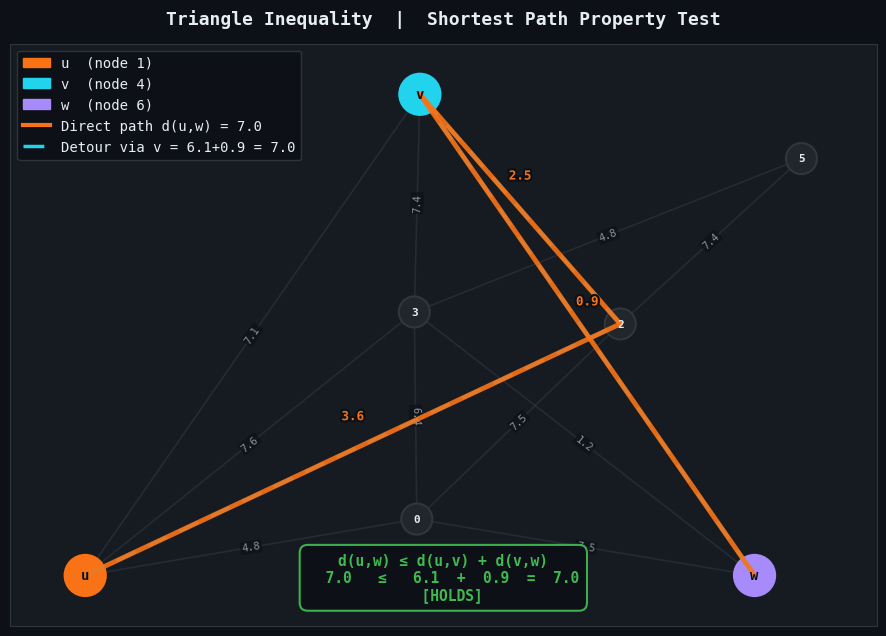


u=1, v=4, w=6
d(u,w) = 7.0
d(u,v) + d(v,w) = 6.1 + 0.9 = 7.0
Triangle inequality: HOLDS


In [3]:
"""
Triangle Inequality Visualization for Shortest Paths
=====================================================
Drop this cell into your Jupyter notebook.
Requires: matplotlib, networkx (both already in your environment).

Shows a random weighted graph with three highlighted nodes u, v, w,
annotating the direct path d(u,w) vs the detour d(u,v)+d(v,w).
Run the cell repeatedly for different random graphs.
"""

import random
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import networkx as nx
import numpy as np

# ── Reproducibility: comment out for fresh graphs each run ───────────────────
# random.seed(42)

# ── Generate a small random weighted graph ───────────────────────────────────
n_nodes  = random.randint(6, 10)
G = nx.Graph()
G.add_nodes_from(range(n_nodes))

for u in range(n_nodes):
    for v in range(u + 1, n_nodes):
        if random.random() < 0.55:
            G.add_edge(u, v, weight=round(random.uniform(0.5, 9.5), 1))

# Ensure connectivity via a random spanning path
nodes = list(range(n_nodes))
random.shuffle(nodes)
for i in range(len(nodes) - 1):
    if not G.has_edge(nodes[i], nodes[i + 1]):
        G.add_edge(nodes[i], nodes[i + 1],
                   weight=round(random.uniform(0.5, 5.0), 1))

# ── Pick three nodes u, v, w that are all mutually reachable ─────────────────
all_pairs = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))

triple = None
node_list = list(G.nodes())
random.shuffle(node_list)
for u in node_list:
    for v in node_list:
        if v == u:
            continue
        for w in node_list:
            if w == u or w == v:
                continue
            if (v in all_pairs.get(u, {}) and
                w in all_pairs.get(u, {}) and
                w in all_pairs.get(v, {})):
                triple = (u, v, w)
                break
        if triple:
            break
    if triple:
        break

if triple is None:
    raise RuntimeError("Could not find a valid (u,v,w) triple -- try re-running.")

u, v, w = triple
d_uw  = all_pairs[u][w]
d_uv  = all_pairs[u][v]
d_vw  = all_pairs[v][w]
detour = d_uv + d_vw
holds  = d_uw <= detour + 1e-8

# ── Shortest paths as edge sequences ─────────────────────────────────────────
def path_edges(G, src, tgt):
    path = nx.shortest_path(G, src, tgt, weight='weight')
    return list(zip(path[:-1], path[1:]))

edges_uw = path_edges(G, u, w)
edges_uv = path_edges(G, u, v)
edges_vw = path_edges(G, v, w)

# ── Layout ───────────────────────────────────────────────────────────────────
pos = nx.spring_layout(G, seed=7, k=1.8)

# Force u, v, w into a clear triangle so they're easy to read
pos[u] = np.array([-0.75, -0.55])
pos[v] = np.array([ 0.00,  0.72])
pos[w] = np.array([ 0.75, -0.55])

# ── Colours ──────────────────────────────────────────────────────────────────
COL_BG      = '#0d1117'
COL_PANEL   = '#161b22'
COL_EDGE    = '#30363d'
COL_NODE    = '#21262d'
COL_LABEL   = '#8b949e'
COL_U       = '#f97316'   # orange
COL_V       = '#22d3ee'   # cyan
COL_W       = '#a78bfa'   # violet
COL_DIRECT  = '#f97316'
COL_DETOUR  = '#22d3ee'
COL_OK      = '#3fb950'
COL_FAIL    = '#f85149'
COL_TEXT    = '#e6edf3'

# ── Figure ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(COL_BG)
ax.set_facecolor(COL_PANEL)
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(
    'Triangle Inequality  |  Shortest Path Property Test',
    color=COL_TEXT, fontsize=13, fontweight='bold',
    fontfamily='monospace', pad=14
)

# ── Draw all edges (background) ──────────────────────────────────────────────
nx.draw_networkx_edges(
    G, pos, ax=ax,
    edge_color=COL_EDGE,
    width=1.2, alpha=0.6,
    style='solid'
)

# Edge weight labels (background edges only -- highlighted ones done below)
highlighted = set(map(frozenset, edges_uw + edges_uv + edges_vw))
edge_labels = {
    (a, b): f"{G[a][b]['weight']}"
    for a, b in G.edges()
    if frozenset([a, b]) not in highlighted
}
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, ax=ax,
    font_color=COL_LABEL, font_size=7.5,
    font_family='monospace',
    bbox=dict(boxstyle='round,pad=0.15', fc=COL_BG, ec='none', alpha=0.7)
)

# ── Draw detour path u->v->w (dashed cyan) ────────────────────────────────────
def draw_highlight_edges(edges, color, lw, style='solid', zorder=3):
    for (a, b) in edges:
        x = [pos[a][0], pos[b][0]]
        y = [pos[a][1], pos[b][1]]
        ax.plot(x, y, color=color, linewidth=lw, linestyle=style,
                solid_capstyle='round', zorder=zorder, alpha=0.9)
        # midpoint weight label
        mx, my = (x[0]+x[1])/2, (y[0]+y[1])/2
        w_val = G[a][b]['weight']
        ax.text(mx, my + 0.07, str(w_val),
                color=color, fontsize=9, ha='center', va='bottom',
                fontfamily='monospace', fontweight='bold',
                path_effects=[pe.withStroke(linewidth=3, foreground=COL_BG)],
                zorder=6)

draw_highlight_edges(edges_uv, COL_DETOUR, lw=2.5, style=(0, (6, 4)))
draw_highlight_edges(edges_vw, COL_DETOUR, lw=2.5, style=(0, (6, 4)))

# ── Draw direct path u->w (solid orange) ─────────────────────────────────────
draw_highlight_edges(edges_uw, COL_DIRECT, lw=3.5)

# ── Draw all nodes ───────────────────────────────────────────────────────────
node_colors = []
node_sizes  = []
node_edge_c = []
node_edge_w = []

uvw_set = {u, v, w}
for nd in G.nodes():
    if nd == u:
        node_colors.append(COL_U);  node_sizes.append(820)
        node_edge_c.append(COL_U);  node_edge_w.append(2.5)
    elif nd == v:
        node_colors.append(COL_V);  node_sizes.append(820)
        node_edge_c.append(COL_V);  node_edge_w.append(2.5)
    elif nd == w:
        node_colors.append(COL_W);  node_sizes.append(820)
        node_edge_c.append(COL_W);  node_edge_w.append(2.5)
    else:
        node_colors.append(COL_NODE); node_sizes.append(500)
        node_edge_c.append(COL_EDGE); node_edge_w.append(1.5)

nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors=node_edge_c,
    linewidths=node_edge_w
)

# Node labels
labels = {nd: ('u' if nd == u else 'v' if nd == v else 'w' if nd == w
               else str(nd))
          for nd in G.nodes()}
label_colors = {nd: (COL_BG if nd in uvw_set else COL_TEXT)
                for nd in G.nodes()}

for nd, lbl in labels.items():
    ax.text(*pos[nd], lbl,
            ha='center', va='center',
            fontsize=10 if nd in uvw_set else 8,
            fontweight='bold', fontfamily='monospace',
            color=label_colors[nd], zorder=8)

# ── Inequality annotation box ─────────────────────────────────────────────────
status_color = COL_OK if holds else COL_FAIL
status_sym   = 'HOLDS' if holds else 'VIOLATED'
ineq_sign    = '\u2264' if holds else '>'

anno = (
    f"d(u,w) {ineq_sign} d(u,v) + d(v,w)\n"
    f"  {d_uw:.1f}   {ineq_sign}   {d_uv:.1f}  +  {d_vw:.1f}  =  {detour:.1f}\n"
    f"  [{status_sym}]"
)

ax.text(
    0.5, 0.04, anno,
    transform=ax.transAxes,
    ha='center', va='bottom',
    fontsize=10.5, fontfamily='monospace', fontweight='bold',
    color=status_color,
    bbox=dict(boxstyle='round,pad=0.55', fc=COL_BG,
              ec=status_color, linewidth=1.5, alpha=0.95)
)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(fc=COL_U,      ec=COL_U,      label=f'u  (node {u})'),
    mpatches.Patch(fc=COL_V,      ec=COL_V,      label=f'v  (node {v})'),
    mpatches.Patch(fc=COL_W,      ec=COL_W,      label=f'w  (node {w})'),
    plt.Line2D([0],[0], color=COL_DIRECT, lw=3,   label=f'Direct path d(u,w) = {d_uw:.1f}'),
    plt.Line2D([0],[0], color=COL_DETOUR, lw=2.5,
               linestyle=(0,(6,4)),                label=f'Detour via v = {d_uv:.1f}+{d_vw:.1f} = {detour:.1f}'),
]
leg = ax.legend(
    handles=legend_elements,
    loc='upper left', fontsize=8,
    facecolor=COL_BG, edgecolor='#30363d',
    labelcolor=COL_TEXT, framealpha=0.95,
    prop={'family': 'monospace'}
)

plt.tight_layout(pad=1.2)
plt.savefig('triangle_inequality.png', dpi=150, bbox_inches='tight',
            facecolor=COL_BG)
plt.show()
print(f"\nu={u}, v={v}, w={w}")
print(f"d(u,w) = {d_uw:.1f}")
print(f"d(u,v) + d(v,w) = {d_uv:.1f} + {d_vw:.1f} = {detour:.1f}")
print(f"Triangle inequality: {'HOLDS' if holds else 'VIOLATED'}")